# Exercise 4.14 — Two Competing Species
**Sayama, *Introduction to the Modeling and Analysis of Complex Systems*, Section 4.6**

---

**Problem:** Develop a discrete-time mathematical model of two species competing for the same resource, and simulate its behavior.

## 1. Model Assumptions

Following the solution walkthrough from Sayama, the model is built on three assumptions:

1. A **finite amount of resource R** is made available at every time step, and all of it is fully consumed by the two species.
2. The **share of resource** each species gets is proportional to its relative population size — the more organisms of a species there are, the faster it consumes.
3. The **population increase** of each species is proportional to the resource it consumed.

These assumptions are intentionally minimal. There is no upper population cap, no predation, and no spatial structure. The only interaction between the species is indirect: they draw from the same fixed resource pool.

## 2. Deriving the Model Equations

Let:
- x, y = population sizes of species X and species Y at time t
- R = total resource available per time step (constant)
- r_x, r_y = growth rates: new offspring born per unit resource consumed

**Step 1 — Resource allocation.**
Since each species consumes proportional to its relative size:

    Resource to X = R * x / (x + y)
    Resource to Y = R * y / (x + y)

Together these sum to R, confirming all resource is consumed.

**Step 2 — Population update.**
New offspring = growth rate * resource consumed, added to existing population:

    x(t) = x(t-1) + r_x * R * x(t-1) / (x(t-1) + y(t-1))
    y(t) = y(t-1) + r_y * R * y(t-1) / (x(t-1) + y(t-1))

These are the **core model equations** (Code 4.13 variant from Sayama).

---

## 3. Analyzing the Ratio x/y

To understand long-run behavior, track the ratio rho = x/y:

    rho(t) = x(t) / y(t)
           = [x + r_x * R * x/N] / [y + r_y * R * y/N]     where N = x + y
           = (x/y) * (1 + r_x * R/N) / (1 + r_y * R/N)
           = rho(t-1) * (1 + r_x * R/N) / (1 + r_y * R/N)

Each step multiplies rho by the factor (1 + r_x*R/N) / (1 + r_y*R/N):

| Condition | Factor | Result |
|---|---|---|
| r_x > r_y | > 1 | rho grows without bound → **X wins** |
| r_x = r_y | = 1 | rho constant → **Neutral coexistence** |
| r_x < r_y | < 1 | rho → 0 → **Y wins** |

This is **competitive exclusion** (Gause's Law): when two species compete for a single resource with different efficiencies, the more efficient one always wins — the outcome depends only on which r is larger, *not* on initial conditions.

The fraction s = x / (x + y) is the cleanest way to visualize this: it converges to 1 if X wins, 0 if Y wins, or stays fixed if r_x = r_y.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 4. Define the Model and Simulation Engine

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────

R = 10.0   # total resource available per time step

# Three scenarios to compare
scenarios = {
    'X wins  (r_x > r_y)': {'r_x': 0.50, 'r_y': 0.30},
    'Neutral (r_x = r_y)': {'r_x': 0.40, 'r_y': 0.40},
    'Y wins  (r_x < r_y)': {'r_x': 0.30, 'r_y': 0.50},
}


# ─────────────────────────────────────────────────────────────────────────────
# SIMULATION ENGINE
# Implements:
#   x(t) = x(t-1) + r_x * R * x(t-1) / (x(t-1) + y(t-1))
#   y(t) = y(t-1) + r_y * R * y(t-1) / (x(t-1) + y(t-1))
# ─────────────────────────────────────────────────────────────────────────────

def simulate(r_x, r_y, x0, y0, steps=120):
    """Run the two-species competition model.

    Returns arrays x, y (absolute populations) and s (fraction of X in total).
    If both populations hit 0 the simulation stops (absorbing state).
    """
    x = np.zeros(steps)
    y = np.zeros(steps)
    x[0], y[0] = float(x0), float(y0)

    for t in range(steps - 1):
        N = x[t] + y[t]
        if N <= 0:
            break
        # Core model equations from Sayama
        x[t+1] = x[t] + r_x * R * (x[t] / N)
        y[t+1] = y[t] + r_y * R * (y[t] / N)

    # Fraction of total population that is species X
    total = x + y
    s = np.where(total > 0, x / total, np.nan)
    return x, y, s


# Quick sanity check
x_test, y_test, s_test = simulate(0.5, 0.3, x0=30, y0=30, steps=5)
print("=== Sanity check: first 5 steps (r_x=0.5, r_y=0.3, x0=y0=30) ===")
print(f"{'t':>4} | {'x':>10} | {'y':>10} | {'x/(x+y)':>10}")
print("-" * 42)
for t in range(5):
    print(f"{t:>4} | {x_test[t]:>10.4f} | {y_test[t]:>10.4f} | {s_test[t]:>10.6f}")

print("\nResource allocation check at t=0:")
x0, y0 = 30.0, 30.0
print(f"  R * x/(x+y) = {R * x0/(x0+y0):.2f}  (X's share)")
print(f"  R * y/(x+y) = {R * y0/(x0+y0):.2f}  (Y's share)")
print(f"  Total consumed = {R * x0/(x0+y0) + R * y0/(x0+y0):.2f} = R = {R}  ✓")

=== Sanity check: first 5 steps (r_x=0.5, r_y=0.3, x0=y0=30) ===
   t |          x |          y |    x/(x+y)
------------------------------------------
   0 |    30.0000 |    30.0000 |   0.500000
   1 |    32.5000 |    31.5000 |   0.507812
   2 |    35.0391 |    32.9766 |   0.515162
   3 |    37.6149 |    34.4311 |   0.522096
   4 |    40.2254 |    35.8648 |   0.528654

Resource allocation check at t=0:
  R * x/(x+y) = 5.00  (X's share)
  R * y/(x+y) = 5.00  (Y's share)
  Total consumed = 10.00 = R = 10.0  ✓


## 5. Simulation — Three Scenarios Side by Side

We run all three scenarios from the same starting point (x0 = y0 = 30) and plot:
- **Top row:** absolute population sizes of X and Y over time
- **Bottom row:** fraction of X in total population — this shows competitive exclusion most clearly

X wins  (r_x > r_y):  x_final=426.5,  y_final=149.1,  s_final=0.7410
Neutral (r_x = r_y):  x_final=268.0,  y_final=268.0,  s_final=0.5000
Y wins  (r_x < r_y):  x_final=149.1,  y_final=426.5,  s_final=0.2590


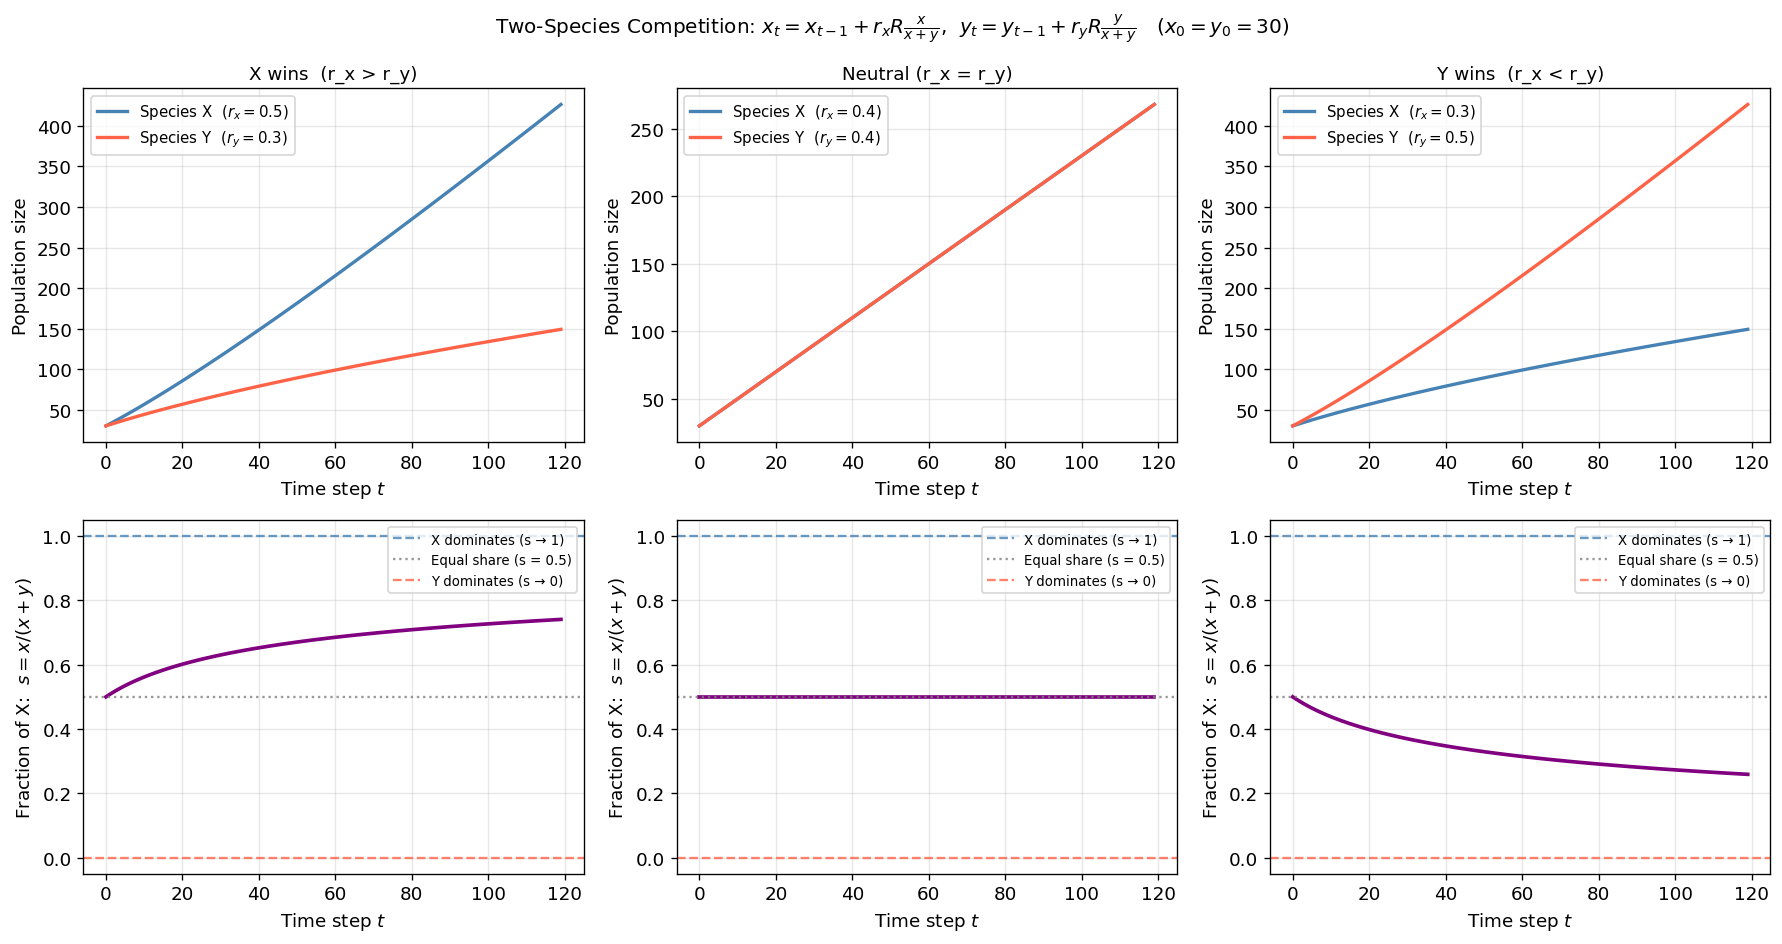

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — Three scenarios: absolute populations and fraction of X
# Both species start equally (x0 = y0 = 30).
# Outcome is determined entirely by which r is larger.
# ─────────────────────────────────────────────────────────────────────────────

x0_eq = 30.0   # equal starting populations
y0_eq = 30.0
steps = 120
t_axis = np.arange(steps)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    r'Two-Species Competition: $x_t = x_{t-1} + r_x R \frac{x}{x+y}$,  '
    r'$y_t = y_{t-1} + r_y R \frac{y}{x+y}$   ($x_0 = y_0 = 30$)',
    fontsize=12)

for col, (label, params) in enumerate(scenarios.items()):
    r_x, r_y = params['r_x'], params['r_y']
    x_arr, y_arr, s_arr = simulate(r_x, r_y, x0_eq, y0_eq, steps)

    # ── Absolute populations (top row) ───────────────────────────────────────
    ax = axes[0, col]
    ax.plot(t_axis, x_arr, color='steelblue',  lw=2.0, label=f'Species X  ($r_x={r_x}$)')
    ax.plot(t_axis, y_arr, color='tomato',     lw=2.0, label=f'Species Y  ($r_y={r_y}$)')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Time step $t$')
    ax.set_ylabel('Population size')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Fraction of X (bottom row) ───────────────────────────────────────────
    ax = axes[1, col]
    ax.plot(t_axis, s_arr, color='purple', lw=2.2)
    ax.axhline(1.0, color='steelblue', linestyle='--', lw=1.4, alpha=0.8,
               label='X dominates (s → 1)')
    ax.axhline(0.5, color='gray',      linestyle=':',  lw=1.4, alpha=0.8,
               label='Equal share (s = 0.5)')
    ax.axhline(0.0, color='tomato',    linestyle='--', lw=1.4, alpha=0.8,
               label='Y dominates (s → 0)')
    ax.set_xlabel('Time step $t$')
    ax.set_ylabel('Fraction of X:  $s = x/(x+y)$')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    print(f"{label}:  x_final={x_arr[-1]:.1f},  y_final={y_arr[-1]:.1f},  "
          f"s_final={s_arr[-1]:.4f}")

plt.tight_layout()
plt.show()

## 6. Initial Conditions Don't Matter (When r_x ≠ r_y)

A key feature of this model: when growth rates differ, the outcome of competition is the same **regardless of starting populations**. Even if the losing species starts with a large advantage, it still loses.

This is the signature of competitive exclusion: the attractor (which species wins) is fixed by r_x vs r_y, not by x0/y0.

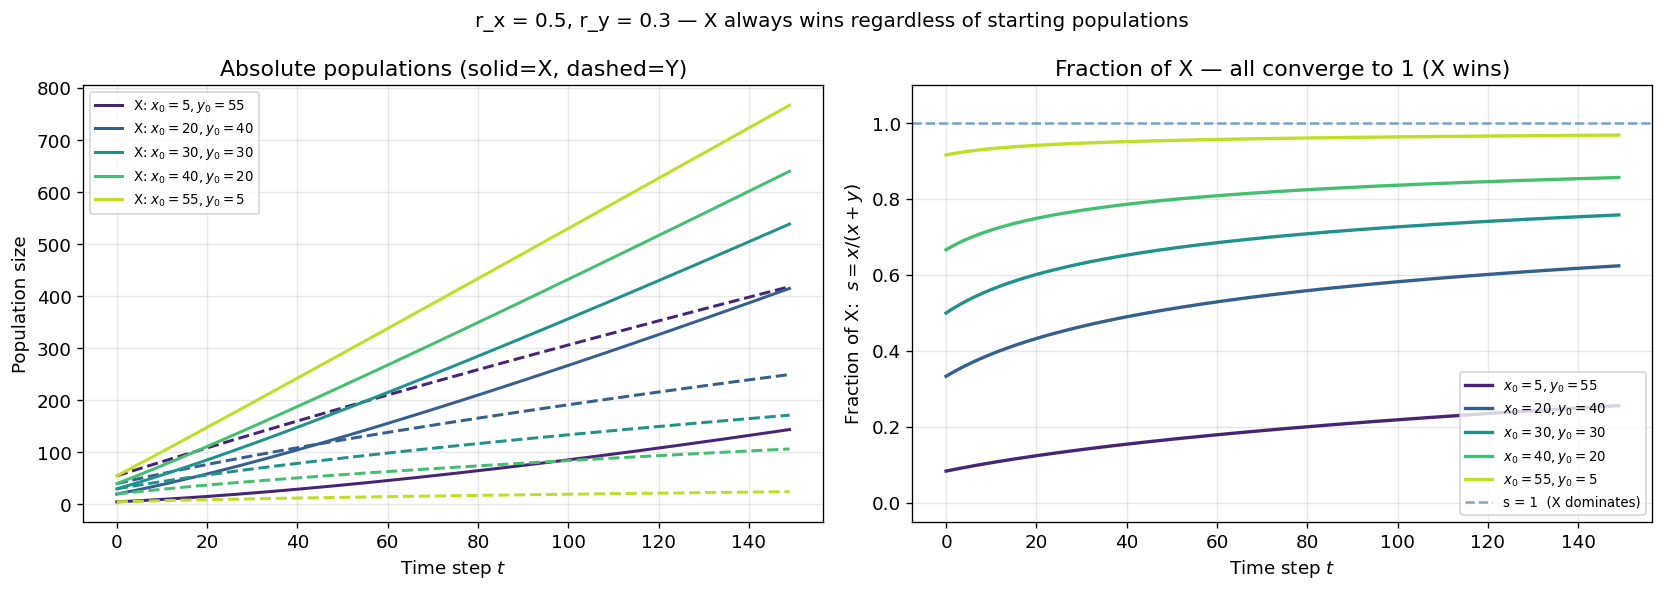

Competitive exclusion confirmed:
  x0=  5, y0= 55  → s_final = 0.255925  (converging...)
  x0= 20, y0= 40  → s_final = 0.624466  (converging...)
  x0= 30, y0= 30  → s_final = 0.758514  (converging...)
  x0= 40, y0= 20  → s_final = 0.857207  (converging...)
  x0= 55, y0=  5  → s_final = 0.969014  (converging...)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — Multiple initial conditions, r_x > r_y (X wins regardless)
# Different x0/y0 ratios all converge to s=1 (X dominates).
# ─────────────────────────────────────────────────────────────────────────────

r_x_win, r_y_win = 0.50, 0.30   # X has higher growth rate
steps = 150
t_axis = np.arange(steps)

# Various starting compositions: (x0, y0) pairs
init_conditions = [
    (5,  55),   # X starts at a big disadvantage
    (20, 40),
    (30, 30),   # equal start
    (40, 20),
    (55,  5),   # X already dominant
]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(init_conditions)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'r_x = {r_x_win}, r_y = {r_y_win} — X always wins regardless of starting populations',
    fontsize=12)

for (x0_val, y0_val), col in zip(init_conditions, colors):
    x_arr, y_arr, s_arr = simulate(r_x_win, r_y_win, x0_val, y0_val, steps)
    lbl = f'$x_0={x0_val}, y_0={y0_val}$'
    axes[0].plot(t_axis, x_arr, color=col, lw=1.8, linestyle='-',  label=f'X: {lbl}')
    axes[0].plot(t_axis, y_arr, color=col, lw=1.8, linestyle='--')
    axes[1].plot(t_axis, s_arr, color=col, lw=2.0, label=lbl)

axes[0].set_xlabel('Time step $t$')
axes[0].set_ylabel('Population size')
axes[0].set_title('Absolute populations (solid=X, dashed=Y)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(1.0, color='steelblue', linestyle='--', lw=1.5, alpha=0.7,
                label='s = 1  (X dominates)')
axes[1].set_xlabel('Time step $t$')
axes[1].set_ylabel('Fraction of X:  $s = x/(x+y)$')
axes[1].set_title('Fraction of X — all converge to 1 (X wins)')
axes[1].set_ylim(-0.05, 1.1)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Competitive exclusion confirmed:")
for (x0_val, y0_val) in init_conditions:
    _, _, s_arr = simulate(r_x_win, r_y_win, x0_val, y0_val, steps)
    print(f"  x0={x0_val:>3}, y0={y0_val:>3}  → s_final = {s_arr[-1]:.6f}  "
          f"({'X dominates' if s_arr[-1] > 0.99 else 'converging...'})") 

## 7. Phase Plane — Trajectories in (x, y) Space

Plotting x vs y directly shows the geometry of competition. The axes are the attractors:
- The **x-axis** (y = 0) is the attractor when r_x > r_y — X drives Y to extinction
- The **y-axis** (x = 0) is the attractor when r_y > r_x — Y drives X to extinction
- The **diagonal** (x = y) is invariant when r_x = r_y — populations stay in their initial ratio

The phase plane makes clear that there is no stable interior equilibrium: trajectories never settle at a point where both species coexist with nonzero populations (unless r_x = r_y exactly).

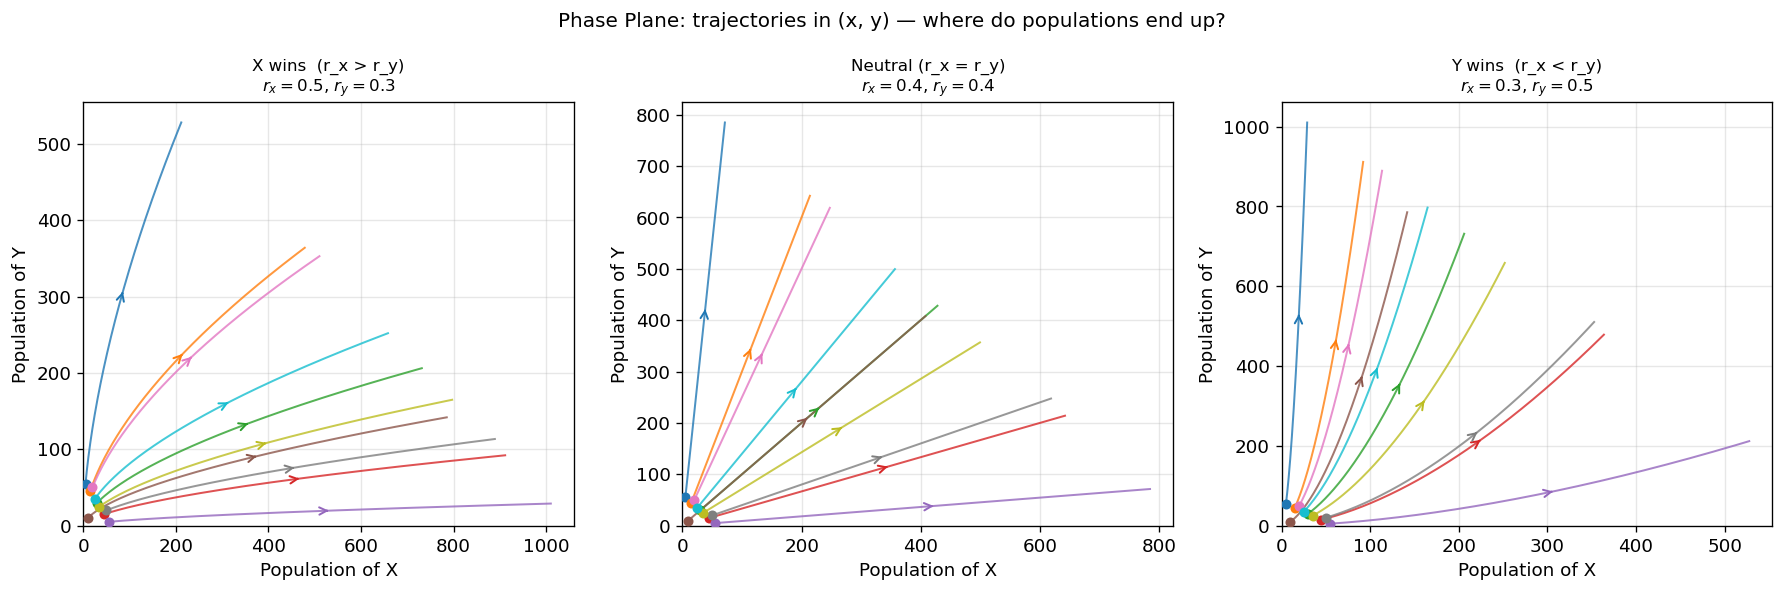

Phase plane interpretation:
  r_x > r_y: all trajectories converge toward the x-axis (Y driven to 0).
  r_x = r_y: trajectories stay on straight lines through the origin (fixed ratio).
  r_x < r_y: all trajectories converge toward the y-axis (X driven to 0).
  No stable interior equilibrium exists — coexistence is not possible in this model.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — Phase plane: trajectories in (x, y) space
# Each panel shows trajectories from multiple starting points.
# Dots mark starting positions; arrowheads show direction of movement.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Phase Plane: trajectories in (x, y) — where do populations end up?',
             fontsize=12)

start_grid = [
    (5, 55), (15, 45), (30, 30), (45, 15), (55, 5),
    (10, 10), (20, 50), (50, 20), (35, 25), (25, 35),
]
phase_colors = plt.cm.tab10(np.linspace(0, 1, len(start_grid)))

for ax, (label, params) in zip(axes, scenarios.items()):
    r_x_p, r_y_p = params['r_x'], params['r_y']

    for (x0_v, y0_v), col in zip(start_grid, phase_colors):
        x_arr, y_arr, _ = simulate(r_x_p, r_y_p, x0_v, y0_v, steps=200)

        # Only plot up to where trajectory is still interesting (both > 0.1)
        alive = np.where((x_arr > 0.1) & (y_arr > 0.1))[0]
        if len(alive) < 2:
            continue
        idx = alive[-1]
        ax.plot(x_arr[:idx+1], y_arr[:idx+1], color=col, lw=1.2, alpha=0.8)
        ax.plot(x_arr[0], y_arr[0], 'o', color=col, ms=5, zorder=5)
        # Arrow at midpoint to show direction
        mid = len(alive) // 2
        if mid > 0:
            ax.annotate('', xy=(x_arr[alive[mid]], y_arr[alive[mid]]),
                        xytext=(x_arr[alive[mid-1]], y_arr[alive[mid-1]]),
                        arrowprops=dict(arrowstyle='->', color=col, lw=1.2))

    ax.set_xlabel('Population of X')
    ax.set_ylabel('Population of Y')
    ax.set_title(f'{label}\n$r_x={r_x_p}$, $r_y={r_y_p}$', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print("Phase plane interpretation:")
print("  r_x > r_y: all trajectories converge toward the x-axis (Y driven to 0).")
print("  r_x = r_y: trajectories stay on straight lines through the origin (fixed ratio).")
print("  r_x < r_y: all trajectories converge toward the y-axis (X driven to 0).")
print("  No stable interior equilibrium exists — coexistence is not possible in this model.")

## 8. Effect of the Growth Rate Ratio r_x / r_y

The speed of competitive exclusion depends on how different the growth rates are. A small advantage (r_x slightly greater than r_y) drives exclusion slowly; a large advantage drives it quickly. This section sweeps over the ratio r_x/r_y and shows how fast s converges to 1.

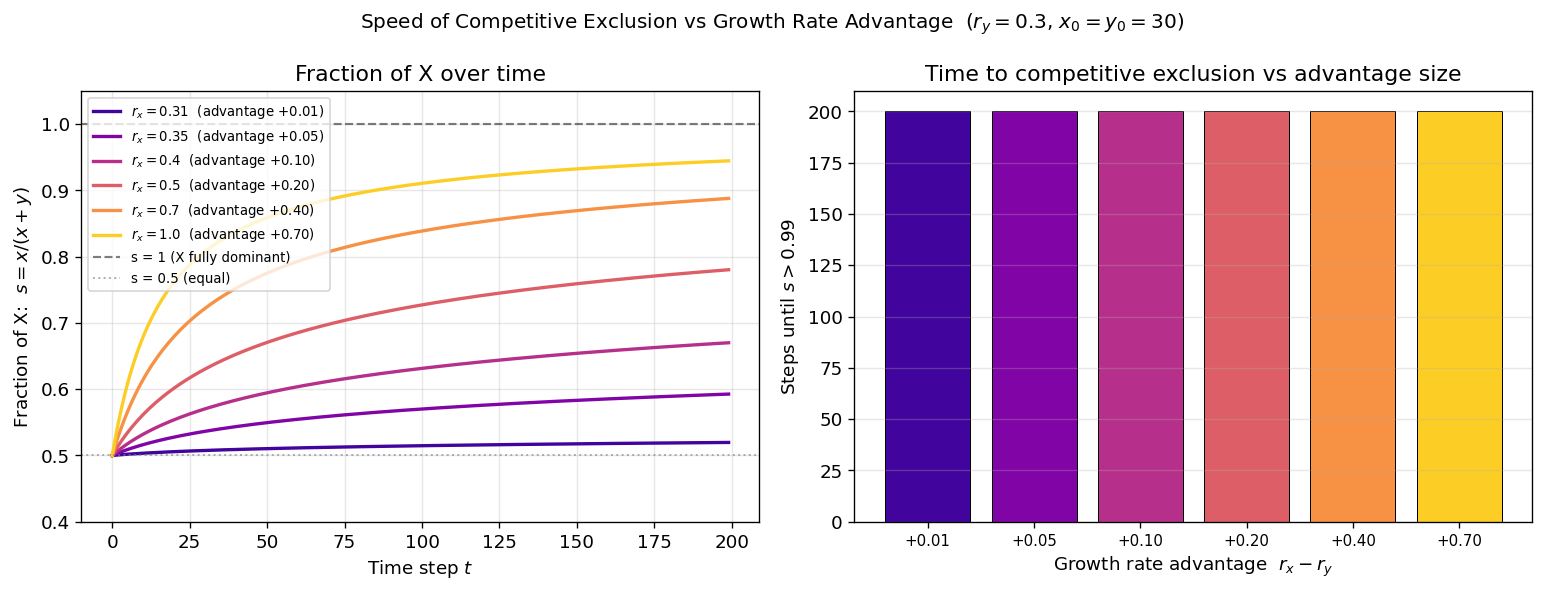

Steps to reach s > 0.99 (X dominates):
  r_x = 0.31, advantage = +0.01 ← not reached in 200 steps
  r_x = 0.35, advantage = +0.05 ← not reached in 200 steps
  r_x = 0.4, advantage = +0.10 ← not reached in 200 steps
  r_x = 0.5, advantage = +0.20 ← not reached in 200 steps
  r_x = 0.7, advantage = +0.40 ← not reached in 200 steps
  r_x = 1.0, advantage = +0.70 ← not reached in 200 steps


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — Speed of exclusion vs magnitude of growth rate difference
# r_y fixed at 0.30; r_x varies from slightly above r_y to much larger.
# ─────────────────────────────────────────────────────────────────────────────

r_y_fixed = 0.30
r_x_values = [0.31, 0.35, 0.40, 0.50, 0.70, 1.00]
steps = 200
t_axis = np.arange(steps)
colors_sweep = plt.cm.plasma(np.linspace(0.1, 0.9, len(r_x_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f'Speed of Competitive Exclusion vs Growth Rate Advantage  '
    f'($r_y = {r_y_fixed}$, $x_0 = y_0 = 30$)',
    fontsize=12)

for r_x_val, col in zip(r_x_values, colors_sweep):
    _, _, s_arr = simulate(r_x_val, r_y_fixed, x0=30, y0=30, steps=steps)
    advantage = r_x_val - r_y_fixed
    lbl = f'$r_x = {r_x_val}$  (advantage +{advantage:.2f})'
    axes[0].plot(t_axis, s_arr, color=col, lw=2.0, label=lbl)

axes[0].axhline(1.0, color='black', linestyle='--', lw=1.3, alpha=0.5, label='s = 1 (X fully dominant)')
axes[0].axhline(0.5, color='gray',  linestyle=':',  lw=1.2, alpha=0.6, label='s = 0.5 (equal)')
axes[0].set_xlabel('Time step $t$')
axes[0].set_ylabel('Fraction of X:  $s = x/(x+y)$')
axes[0].set_title('Fraction of X over time')
axes[0].set_ylim(0.4, 1.05)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# How many steps until s > 0.99 (90 threshold)
times_to_dominate = []
for r_x_val in r_x_values:
    _, _, s_arr = simulate(r_x_val, r_y_fixed, x0=30, y0=30, steps=steps)
    cross = np.where(s_arr > 0.99)[0]
    t_dom = cross[0] if len(cross) > 0 else steps
    times_to_dominate.append(t_dom)

advantages = [r_x - r_y_fixed for r_x in r_x_values]
axes[1].bar(range(len(r_x_values)), times_to_dominate,
            color=colors_sweep, edgecolor='black', linewidth=0.6)
axes[1].set_xticks(range(len(r_x_values)))
axes[1].set_xticklabels([f'+{a:.2f}' for a in advantages], fontsize=9)
axes[1].set_xlabel('Growth rate advantage  $r_x - r_y$')
axes[1].set_ylabel('Steps until $s > 0.99$')
axes[1].set_title('Time to competitive exclusion vs advantage size')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Steps to reach s > 0.99 (X dominates):")
for r_x_val, t_dom in zip(r_x_values, times_to_dominate):
    marker = f" ← {t_dom} steps" if t_dom < steps else f" ← not reached in {steps} steps"
    print(f"  r_x = {r_x_val}, advantage = +{r_x_val - r_y_fixed:.2f}{marker}")

## 9. Summary — Model Behavior and Comparison to Logistic Growth

### The Model

    x(t) = x(t-1) + r_x * R * x(t-1) / (x(t-1) + y(t-1))
    y(t) = y(t-1) + r_y * R * y(t-1) / (x(t-1) + y(t-1))

Each species claims a share of the fixed resource pool R, with that share proportional to its current population size. Growth is then proportional to resource consumed.

### Key Results

| Condition | Outcome | Why |
|---|---|---|
| r_x > r_y | X wins; Y → extinction | Each step, X gains a proportionally larger boost from the same resource |
| r_x = r_y | Neutral coexistence; ratio x/y stays fixed | Both species gain equal per-capita benefit; no selective pressure |
| r_x < r_y | Y wins; X → extinction | Same logic, Y is the more efficient converter |

### Outcome is Independent of Initial Conditions

The winner is determined **only by which growth rate is larger**, not by how many individuals each species starts with. Even a species that starts with 10x the population of a competitor will still lose if its growth rate is lower. This is because the ratio x/y is multiplied by (1 + r_x*R/N)/(1 + r_y*R/N) at every step — if r_x > r_y, that factor is always > 1, pushing x/y higher regardless of the starting value.

### Gause's Law (Competitive Exclusion Principle)

This result is a discrete-time demonstration of **Gause's Law**: two species competing for a single limiting resource cannot stably coexist — the one with even a slight efficiency advantage will eventually drive the other to extinction. The only exception is perfect equality (r_x = r_y exactly), which is a non-generic, measure-zero case.

### Contrast with the Single-Species Models (Ch. 4.5)

| Model | Equilibrium | Depends on initial conditions? |
|---|---|---|
| Logistic (Eq. 4.21) | Single stable carrying capacity K | No — all x0 > 0 reach K |
| Parabolic / Allee (Ex. 4.10) | Two equilibria: unstable x- and stable x+ | Yes — x0 < x- → extinct |
| Two-species competition (Ex. 4.14) | One species axis (no interior stable point) | No — winner fixed by r_x vs r_y, not x0, y0 |

The two-species model adds a new kind of history-independence: not only does it not matter where you start, the entire trajectory is governed by a single parameter comparison (r_x vs r_y).